## PHÂN TÍCH VÀ XẾP HẠNG XE MÁY TẠI VIỆT NAM

### Mục tiêu nghiên cứu

Nghiên cứu xây dựng hệ thống hỗ trợ ra quyết định lựa chọn xe máy dựa trên dữ liệu thực tế về các mẫu xe trên thị trường và mức độ ưu tiên của người dùng.

Quy trình phân tích bao gồm:

1. Thu thập và tổng hợp dữ liệu xe máy.
2. Làm sạch và tiền xử lý dữ liệu.
3. Xử lý giá trị thiếu và chuẩn hóa dữ liệu.
4. Thu thập mức độ quan trọng của các tiêu chí thông qua khảo sát.
5. Tính trọng số cho từng tiêu chí.
6. Áp dụng phương pháp TOPSIS để xếp hạng các phương án.
7. Trực quan hóa và phân tích kết quả.

### Phương pháp nghiên cứu

Phương pháp TOPSIS được sử dụng để đánh giá và xếp hạng các phương án xe máy dựa trên nhiều tiêu chí đồng thời.

In [73]:
import pandas as pd
import numpy as np
from IPython.core.magics import display

### 1. THU THẬP VÀ EDA

#### 1. Nạp dữ liệu xử lý dữ liệu trùng lặp


In [74]:
crawl_df = pd.read_csv("crawl_data.csv")

In [75]:
# Xoá duplicate, có dòng sym - priti bị dup
brand_col = crawl_df.columns[0]
crawl_df = crawl_df.drop_duplicates(subset=[brand_col, 'model', 'variant', 'version']).copy()

#### 1.2. Chuẩn hóa thông tin nhận diện xe

Thông tin tên xe được tổng hợp từ các thuộc tính như thương hiệu, mẫu xe, phiên bản và version.

Mục tiêu của bước này là tạo một thuộc tính định danh thống nhất cho từng phương án xe.

In [76]:
crawl_df['version_clean'] = crawl_df['version'].replace(['NULL', 'null', np.nan], '').astype(str).str.strip()
crawl_df['bike_name'] = crawl_df[brand_col].astype(str).str.strip() + " " + \
                        crawl_df['model'].astype(str).str.strip() + " " + \
                        crawl_df['version_clean']
crawl_df['bike_name'] = crawl_df['bike_name'].str.strip()

### 2. LỰA CHỌN CÁC TIÊU CHÍ ĐÁNH GIÁ

Không phải tất cả các thuộc tính trong dữ liệu đều được sử dụng cho quá trình ra quyết định.

Nghiên cứu lựa chọn các tiêu chí có ảnh hưởng trực tiếp đến quyết định mua xe của người dùng.

Các tiêu chí được sử dụng bao gồm:

| Nhóm thông tin | Tiêu chí |
|---|---|
| Thông tin nhận diện | Tên xe, loại xe, hệ truyền động |
| Chi phí | Giá bán, mức tiêu thụ nhiên liệu |
| Hiệu năng | Công suất tối đa |
| Tiện ích | Dung tích cốp xe |
| An toàn | Hệ thống chống bó cứng phanh ABS |
| Đặc tính kỹ thuật | Trọng lượng xe |
| Dịch vụ sau bán hàng | Thời gian bảo hành |

Các tiêu chí này sẽ được sử dụng trong phương pháp TOPSIS để đánh giá và xếp hạng các phương án xe.

In [77]:
selected_cols = [
    'bike_name', 'vehicle_type', 'powertrain',
    'price_vnd', 'fuel_consumption_l_per_100km', 'max_power_kw',
    'underseat_storage_l', 'abs', 'curb_weight_kg', 'vehicle_warranty_months'
]

bikes = crawl_df[selected_cols].copy()

### 3. TIỀN XỬ LÝ DỮ LIỆU

In [78]:
# Chuyển "NULL" -> NaN + ép kiểu
numeric_cols = ['price_vnd', 'fuel_consumption_l_per_100km', 'max_power_kw',
                'underseat_storage_l', 'curb_weight_kg', 'vehicle_warranty_months']

for col in numeric_cols:
    bikes[col] = bikes[col].replace(['NULL', 'null', 'None'], np.nan)
    bikes[col] = pd.to_numeric(bikes[col], errors='coerce')

In [79]:
bikes['abs'] = bikes['abs'].map({True: 1, 'TRUE': 1, 'True': 1, 1: 1, '1': 1, False: 0, 'FALSE': 0, 'False': 0, 0: 0, '0': 0}).fillna(0).astype(int)

### 4. XỬ LÝ GIÁ TRỊ THIẾU

#### Phương pháp xử lý

- Thời gian bảo hành: sử dụng giá trị mặc định theo giả định nghiên cứu.
- Các biến định lượng: thay thế bằng giá trị trung vị.
- Giá bán: loại bỏ các phương án không có thông tin giá.

In [80]:
# Missing value:

# Set bảo hành fillna 36 tháng
bikes['vehicle_warranty_months'] = bikes['vehicle_warranty_months'].fillna(36)
# Median
for col in ['fuel_consumption_l_per_100km', 'max_power_kw', 'underseat_storage_l', 'curb_weight_kg']:
    bikes[col] = bikes[col].fillna(bikes[col].median())

In [81]:
bikes = bikes.dropna(subset=['price_vnd']).reset_index(drop=True)

In [82]:
bikes.head(5)

,bike_name,vehicle_type,powertrain,price_vnd,fuel_consumption_l_per_100km,max_power_kw,underseat_storage_l,abs,curb_weight_kg,vehicle_warranty_months
0,Honda Air Blade phiên bản Thể Thao,xe tay ga,ICE,58790000.0,2.23,11.20,23.2,0,113.0,36.0
1,Honda Air Blade phiên bản Đặc Biệt,xe tay ga,ICE,58290000.0,2.23,11.20,23.2,0,113.0,36.0
2,Honda Air Blade phiên bản Tiêu Chuẩn,xe tay ga,ICE,57090000.0,2.23,11.20,23.2,0,113.0,36.0
3,Honda Air Blade phiên bản Thể Thao,xe tay ga,ICE,48001091.0,2.12,8.75,23.2,0,111.0,36.0
4,Honda Air Blade phiên bản Đặc Biệt,xe tay ga,ICE,43582909.0,2.12,8.75,23.2,0,110.0,36.0


In [83]:
print("Missing Values check")
print(bikes.isnull().sum())

Missing Values check
bike_name                       0
vehicle_type                    0
powertrain                      0
price_vnd                       0
fuel_consumption_l_per_100km    0
max_power_kw                    0
underseat_storage_l             0
abs                             0
curb_weight_kg                  0
vehicle_warranty_months         0
dtype: int64


In [84]:
bikes.to_csv("cleaned_motorbikes.csv", index=False, encoding="utf-8-sig")
print("\nĐã lưu: 'cleaned_motorbikes.csv'")


Đã lưu: 'cleaned_motorbikes.csv'


### 5. XÁC ĐỊNH TRỌNG SỐ TIÊU CHÍ TỪ KHẢO SÁT NGƯỜI DÙNG (TÍNH WEIGHTS VECTOR)

#### 5.1. Cơ sở xác định trọng số

Trong bài toán lựa chọn xe máy, mức độ quan trọng của các tiêu chí có thể khác nhau đối với người dùng.

Ví dụ, một số người dùng ưu tiên giá bán, trong khi những người khác quan tâm nhiều hơn đến công suất, mức tiêu thụ nhiên liệu hoặc các tính năng an toàn.

Do đó, thay vì gán trọng số chủ quan, nghiên cứu sử dụng dữ liệu khảo sát để xác định mức độ ưu tiên trung bình của người dùng đối với từng tiêu chí.

Các trọng số thu được sẽ được sử dụng trong bước tính toán TOPSIS.

In [85]:
survey_df = pd.read_csv("survey_data.csv")

In [86]:
# ánh xạ: [Tên tiêu chí xe] <---> [Cột khảo sát tương ứng]
survey_mapping = {
    'price_vnd': [col for col in survey_df.columns if 'Giá mua' in col][0],
    'fuel_consumption_l_per_100km': [col for col in survey_df.columns if 'Chi phí vận hành' in col][0],
    'max_power_kw': [col for col in survey_df.columns if 'Hiệu năng' in col][0],
    'underseat_storage_l': [col for col in survey_df.columns if 'Khả năng chứa đồ'in col][0],
    'abs': [col for col in survey_df.columns if 'An toàn' in col][0],
    'curb_weight_kg': [col for col in survey_df.columns if 'Trọng lượng' in col][0],
    'vehicle_warranty_months': [col for col in survey_df.columns if 'bảo hành' in col][0]
}
survey_mapping

{'price_vnd': '7. Hãy đánh giá mức độ quan trọng của các yếu tố sau khi lựa chọn xe. [Giá mua]',
 'fuel_consumption_l_per_100km': '7. Hãy đánh giá mức độ quan trọng của các yếu tố sau khi lựa chọn xe. [Chi phí vận hành]',
 'max_power_kw': '7. Hãy đánh giá mức độ quan trọng của các yếu tố sau khi lựa chọn xe. [Hiệu năng]',
 'underseat_storage_l': '7. Hãy đánh giá mức độ quan trọng của các yếu tố sau khi lựa chọn xe. [Khả năng chứa đồ]',
 'abs': '7. Hãy đánh giá mức độ quan trọng của các yếu tố sau khi lựa chọn xe. [An toàn]',
 'curb_weight_kg': '7. Hãy đánh giá mức độ quan trọng của các yếu tố sau khi lựa chọn xe. [Trọng lượng / kích thước]',
 'vehicle_warranty_months': '7. Hãy đánh giá mức độ quan trọng của các yếu tố sau khi lựa chọn xe. [Độ bền / bảo hành]'}

#### 5.2. Tính mức độ quan trọng trung bình

Đối với mỗi tiêu chí, điểm đánh giá của tất cả người tham gia khảo sát được tổng hợp.

Điểm quan trọng trung bình được tính theo công thức:

$$
\bar{x}_j = \frac{1}{n}\sum_{i=1}^{n} x_{ij}
$$

Trong đó:

- x̄ⱼ là điểm trung bình của tiêu chí j.
- xᵢⱼ là điểm đánh giá của người tham gia i đối với tiêu chí j.
- n là tổng số người tham gia khảo sát.

Điểm trung bình càng cao cho thấy tiêu chí đó được người dùng đánh giá càng quan trọng.

In [87]:
mean_scores = {}
for criterion, survey_col in survey_mapping.items():
    # trích số 1-5 bằng regex
    scores = survey_df[survey_col].astype(str).str.extract(r'(\d+)')[0]
    scores = pd.to_numeric(scores, errors='coerce')
    # mean scores
    mean_scores[criterion] = scores.mean()

In [88]:
# normalize sao cho tổng weight = 1.0 (100%)
weights_df = pd.DataFrame(list(mean_scores.items()), columns=['Criterion', 'Mean_Score'])

In [89]:
# Tính Weight chuẩn hóa: Weight = Mean_Score / Tổng Mean_Score
total_score = weights_df['Mean_Score'].sum()
weights_df['Weight'] = weights_df['Mean_Score'] / total_score

#### 5.3 Phân loại tiêu chí

Các tiêu chí được phân thành hai nhóm: Benefit (càng lớn càng tốt) và Cost (càng nhỏ càng tốt).

In [90]:
# Thêm các cột tiêu chí để phục vụ TOPSIS
criteria_types = {
    'price_vnd': 'Cost',
    'fuel_consumption_l_per_100km': 'Cost',
    'curb_weight_kg': 'Cost',
    'max_power_kw': 'Benefit',
    'underseat_storage_l': 'Benefit',
    'abs': 'Benefit',
    'vehicle_warranty_months': 'Benefit'
}
weights_df['Type'] = weights_df['Criterion'].map(criteria_types)

In [91]:
print("BẢNG TRỌNG SỐ TIÊU CHÍ NGƯỜI DÙNG")

weights_df
print(f"Kiểm tra tổng trọng số: {weights_df['Weight'].sum():.4f} (Đạt chuẩn 1.0 = 100%)")

BẢNG TRỌNG SỐ TIÊU CHÍ NGƯỜI DÙNG
Kiểm tra tổng trọng số: 1.0000 (Đạt chuẩn 1.0 = 100%)


In [92]:
weights_df.to_csv("criteria_weights.csv", index=False, encoding="utf-8-sig")
print("Đã lưu file: 'criteria_weights.csv'")

Đã lưu file: 'criteria_weights.csv'


### 6. ÁP DỤNG THUẬT TOÁN TOPSIS & XẾP HẠNG  XE

In [93]:
def run_topsis(bikes_df, weights_df):
    """
    Input:
        - bikes_df: DataFrame danh sách xe và các thông số
        - weights_df: DataFrame gồm 'Criterion', 'Weight', 'Type' (Cost/Benefit)
    Output:
        - DataFrame kết quả đã có cột điểm số Closeness_Score (Ci) và Rank
    """
    df = bikes_df.copy()
    criteria = weights_df['Criterion'].tolist()
    weights = weights_df['Weight'].values
    types = weights_df['Type'].tolist()

    # 1.
    X = df[criteria].values.astype(float)

    # 2.
    ## 2.1
        # r_ij = x_ij / sqrt(sum(x_ij^2))
    norm_factors = np.sqrt((X**2).sum(axis=0))
    # Tránh chia cho 0 nếu có cột toàn số 0
    norm_factors[norm_factors == 0] = 1.0
    R = X / norm_factors

    ## 2.2. Nhân trọng số người dùng
    V = R * weights

    ## 2.3. Tìm điểm lý tưởng tốt nhất (A+) và kém nhất (A-)
    A_plus = np.zeros(len(criteria))
    A_minus = np.zeros(len(criteria))

    for j in range(len(criteria)):
        if types[j] == 'Benefit':
            A_plus[j] = np.max(V[:, j])   # Benefit: càng cao càng tốt
            A_minus[j] = np.min(V[:, j])  # Benefit: càng thấp càng tệ
        else: # Cost
            A_plus[j] = np.min(V[:, j])   # Cost: càng thấp càng tốt
            A_minus[j] = np.max(V[:, j])  # Cost: càng cao càng tệ

    ## 2.4. Tính khoảng cách Euclidean (S+ và S-)
    S_plus = np.sqrt(((V - A_plus)**2).sum(axis=1))
    S_minus = np.sqrt(((V - A_minus)**2).sum(axis=1))

    ## 2.5. Tính điểm số tương đối Closeness Coefficient (Ci)
        # Ci = S- / (S+ + S-)
    C = S_minus / (S_plus + S_minus)

    # Gắn kết quả vào DataFrame
    df['Distance_Best (S+)'] = S_plus.round(4)
    df['Distance_Worst (S-)'] = S_minus.round(4)
    df['TOPSIS_Score (Ci)'] = C.round(4)

    # Xếp hạng: điểm Ci cao nhất xếp hạng 1
    df['Rank'] = df['TOPSIS_Score (Ci)'].rank(ascending=False, method='min').astype(int)

    # Sắp xếp lại theo thứ hạng từ 1 đến hết
    df = df.sort_values('Rank').reset_index(drop=True)
    return df

print("Đã khởi tạo hàm tính toán TOPSIS")

Đã khởi tạo hàm tính toán TOPSIS


In [94]:
cleaned_motorbikes = pd.read_csv("cleaned_motorbikes.csv")
criteria_weights = pd.read_csv("criteria_weights.csv")

results_df = run_topsis(cleaned_motorbikes, criteria_weights)

# Hiển thị Top 10 chiếc xe xuất sắc nhất thị trường
display_cols = ['Rank', 'bike_name', 'vehicle_type', 'price_vnd', 'fuel_consumption_l_per_100km',
                'max_power_kw', 'underseat_storage_l', 'abs', 'TOPSIS_Score (Ci)']

print(" ================= TOP 10 XE ĐÁNG MUA NHẤT THEO TIÊU CHÍ =================")
results_df[display_cols].head(10)

 ================= TOP 10 XE ĐÁNG MUA NHẤT THEO TIÊU CHÍ =================


,Rank,bike_name,vehicle_type,price_vnd,fuel_consumption_l_per_100km,max_power_kw,underseat_storage_l,abs,TOPSIS_Score (Ci)
0,1,Yamaha NVX ABS,xe tay ga,55300000.0,2.21,11.3,25.0,1,0.8101
1,2,Yamaha Lexi phiên bản tiêu chuẩn,xe tay ga,48500000.0,2.19,11.3,20.0,1,0.8086
2,3,Yamaha Lexi phiên bản tiêu chuẩn mới,xe tay ga,48900000.0,2.19,11.3,20.0,1,0.8085
3,3,Yamaha Lexi phiên bản cao cấp,xe tay ga,48900000.0,2.19,11.3,20.0,1,0.8085
4,5,Yamaha Lexi phiên bản cao cấp mới,xe tay ga,49900000.0,2.19,11.3,20.0,1,0.8081
5,6,Yamaha NMAX Standard,xe tay ga,69000000.0,2.26,11.1,24.0,1,0.8009
6,7,Kymco Xciting S350,xe tay ga,115000000.0,2.07,28.5,20.0,1,0.7989
7,8,Yamaha NMAX Tech Max,xe tay ga,79000000.0,2.30,11.3,25.0,1,0.7968
8,9,Yamaha Freego phiên bản đặc biệt,xe tay ga,34265500.0,2.03,7.0,25.0,1,0.7930
9,10,Yamaha Freego phiên bản đặc biệt màu mới,xe tay ga,34855000.0,2.03,7.0,25.0,1,0.7929


### 7. TRỰC QUAN HÓA VÀ PHÂN TÍCH KẾT QUẢ

Kết quả xếp hạng được trực quan hóa để phân tích các phương án và so sánh giữa các nhóm xe.

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

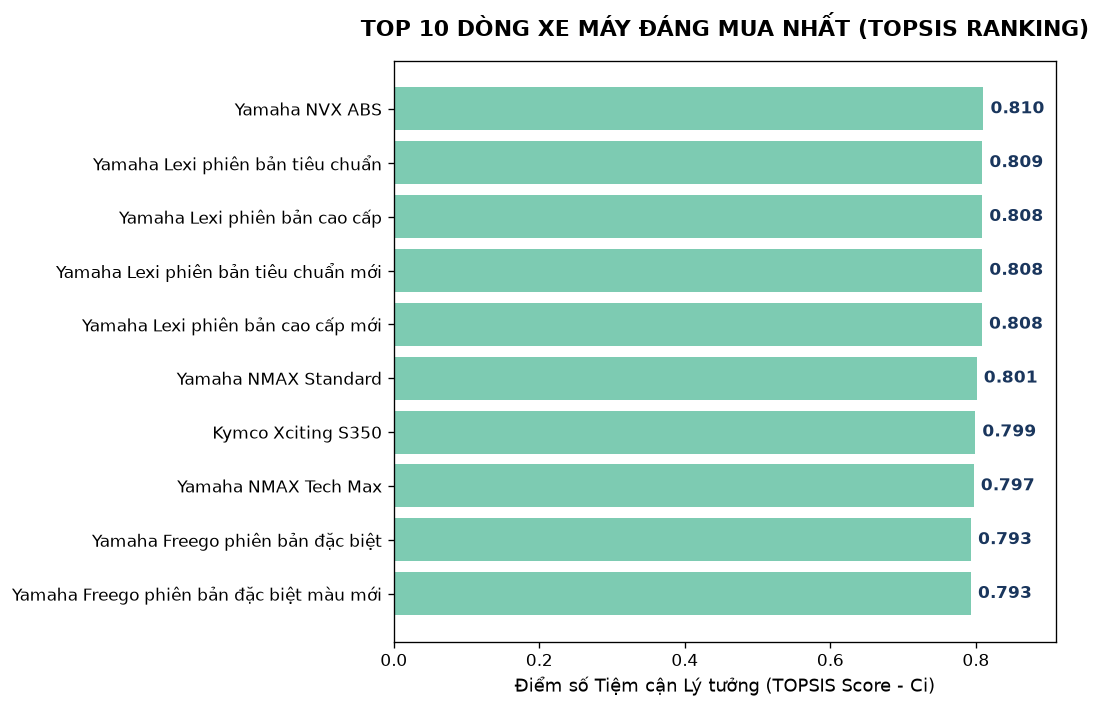

In [96]:
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# BIỂU ĐỒ 1: TOP 10 XE CÓ ĐIỂM SỐ TOPSIS CAO NHẤT
top10 = results_df.head(10).sort_values('TOPSIS_Score (Ci)', ascending=True)
plt.figure(figsize=(9, 6))
bars = plt.barh(top10['bike_name'], top10['TOPSIS_Score (Ci)'], alpha=0.85)

# điểm số
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.3f}',
             va='center', ha='left', fontsize=10, fontweight='bold', color='#1a365d')

plt.title('TOP 10 DÒNG XE MÁY ĐÁNG MUA NHẤT (TOPSIS RANKING)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Điểm số Tiệm cận Lý tưởng (TOPSIS Score - Ci)', fontsize=11)
plt.xlim(0, max(top10['TOPSIS_Score (Ci)']) + 0.1)
plt.tight_layout()
plt.show()

C:\Users\UYEN NHI\AppData\Local\Temp\ipykernel_4564\2874079969.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='vehicle_type', y='TOPSIS_Score (Ci)', palette='Pastel1', ax=ax1)


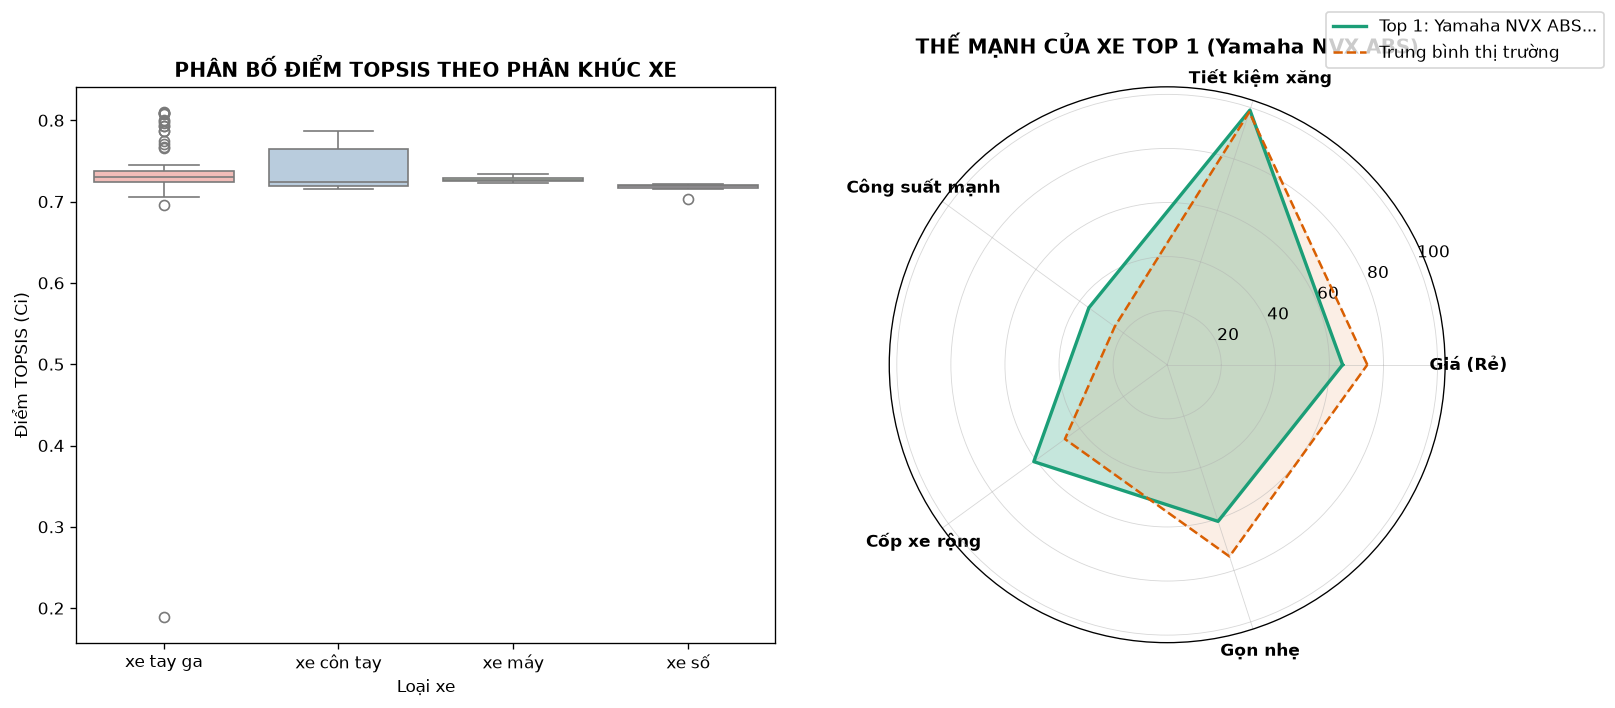

In [97]:
# BIỂU ĐỒ BOXPLOT SO SÁNH GIỮA CÁC PHÂN KHÚC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot phân khúc
sns.boxplot(data=results_df, x='vehicle_type', y='TOPSIS_Score (Ci)', palette='Pastel1', ax=ax1)
ax1.set_title('PHÂN BỐ ĐIỂM TOPSIS THEO PHÂN KHÚC XE', fontsize=12, fontweight='bold')
ax1.set_xlabel('Loại xe', fontsize=10)
ax1.set_ylabel('Điểm TOPSIS (Ci)', fontsize=10)

# BIỂU ĐỒ RADAR CHART SO SÁNH TOP 1 VS TRUNG BÌNH THỊ TRƯỜNG
# Chuẩn hóa min-max 5 tiêu chí trực quan về thang 0-100 để vẽ radar
radar_criteria = ['price_vnd', 'fuel_consumption_l_per_100km', 'max_power_kw', 'underseat_storage_l', 'curb_weight_kg']
labels = ['Giá (Rẻ)', 'Tiết kiệm xăng', 'Công suất mạnh', 'Cốp xe rộng', 'Gọn nhẹ']

top1_bike = results_df.iloc[0]
avg_bike = results_df.mean(numeric_only=True)

# Đảo ngược tiêu chí Cost để càng to càng tốt trên biểu đồ Radar
def get_radar_values(row):
    v_price = 100 - (row['price_vnd'] - results_df['price_vnd'].min()) / (results_df['price_vnd'].max() - results_df['price_vnd'].min()) * 100
    v_fuel = 100 - (row['fuel_consumption_l_per_100km'] - results_df['fuel_consumption_l_per_100km'].min()) / (results_df['fuel_consumption_l_per_100km'].max() - results_df['fuel_consumption_l_per_100km'].min()) * 100
    v_power = (row['max_power_kw'] - results_df['max_power_kw'].min()) / (results_df['max_power_kw'].max() - results_df['max_power_kw'].min()) * 100
    v_storage = (row['underseat_storage_l'] - results_df['underseat_storage_l'].min()) / (results_df['underseat_storage_l'].max() - results_df['underseat_storage_l'].min()) * 100
    v_weight = 100 - (row['curb_weight_kg'] - results_df['curb_weight_kg'].min()) / (results_df['curb_weight_kg'].max() - results_df['curb_weight_kg'].min()) * 100
    return [v_price, v_fuel, v_power, v_storage, v_weight]

top1_vals = get_radar_values(top1_bike)
avg_vals = get_radar_values(avg_bike)

# Vẽ Radar
ax2.remove()
ax2 = fig.add_subplot(1, 2, 2, polar=True)
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
top1_vals += top1_vals[:1]
avg_vals += avg_vals[:1]
angles += angles[:1]

ax2.plot(angles, top1_vals, color='#1b9e77', linewidth=2, label=f"Top 1: {top1_bike['bike_name'][:20]}...")
ax2.fill(angles, top1_vals, color='#1b9e77', alpha=0.25)

ax2.plot(angles, avg_vals, color='#d95f02', linewidth=1.5, linestyle='--', label='Trung bình thị trường')
ax2.fill(angles, avg_vals, color='#d95f02', alpha=0.1)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(labels, fontsize=10, fontweight='bold')
ax2.set_title(f'THẾ MẠNH CỦA XE TOP 1 ({top1_bike["bike_name"]})', fontsize=12, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15))

plt.tight_layout()
plt.show()